# Recommendation System Evaluation

This notebook demonstrates comprehensive evaluation and visualization of Content-Based, Collaborative Filtering, and Hybrid recommendation models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_processing.data_loader import MovieLensDataLoader
from src.models.content_based import ContentBasedRecommender, ContentBasedConfig
from src.models.collaborative_filtering import CollaborativeFiltering
from src.models.hybrid import HybridRecommender
from src.models.cascading_hybrid import CascadingHybridRecommender
from src.models.popular_baseline_model import PopularityBaseline
from src.evaluation.evaluator import RecommendationEvaluator
from src.evaluation.visualisation import RecommendationVisualizer
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)

## 1. Load and Prepare Data

In [ ]:
loader = MovieLensDataLoader()
data_dict = loader.load_data()
await loader.letterboxd_data_async(max_concurrent_requests=100)

movies_df = pd.DataFrame(loader.movie_data)
ratings_df = data_dict['ratings']
genre_features = loader.preprocess_movies()
movies_df = pd.concat([movies_df, genre_features], axis=1)
movies_df = movies_df.dropna().reset_index(drop=True)

print(f"Movies: {len(movies_df)}")
print(f"Ratings: {len(ratings_df)}")
print(f"Users: {ratings_df['userId'].nunique()}")

INFO:src.data_processing.data_loader:Loading MovieLens dataset...
INFO:src.data_processing.data_loader:Loading existing data from cache: data/processed/movie_metadata.csv
INFO:src.data_processing.data_loader:Found 761 missing movies with valid TMDB IDs. Fetching...
INFO:src.data_processing.data_loader:Fetch completed. Successfully downloaded: 14. Failed/Skipped: 747.
INFO:src.data_processing.data_loader:Cache updated and saved to data/processed/movie_metadata.csv


Movies: 8953
Ratings: 100836
Users: 610


## 2. Split Data (Temporal Split)

In [3]:
ratings_df = ratings_df.sort_values('timestamp')
split_idx = int(len(ratings_df) * 0.8)

train_df = ratings_df.iloc[:split_idx].copy()
test_df = ratings_df.iloc[split_idx:].copy()

print(f"Train set: {len(train_df)} ratings")
print(f"Test set: {len(test_df)} ratings")
print(f"Train users: {train_df['userId'].nunique()}")
print(f"Test users: {test_df['userId'].nunique()}")

Train set: 80668 ratings
Test set: 20168 ratings
Train users: 522
Test users: 116


## 3. Train Models

In [4]:
#tags_df = pd.read_csv('/home/aquathirsty/Desktop/PFE/film-recommendations/data/raw/movielens/ml-latest-small/tags.csv')

config = ContentBasedConfig(
    main_actor_weight=0.3,
    director_weight=0.3,
    cast_weight=0.3,
    keywords_weight=0.6,
    numerical_weight=0.1,
    similarity_threshold=0.15,
    top_k_default=20
)

cb_model = ContentBasedRecommender(config=config)
cb_model.fit(movies_df=movies_df, ratings_df=train_df)
print("Content-Based model with tags trained successfully!")

Content-Based model with tags trained successfully!


In [5]:
cf_model = CollaborativeFiltering(k_components=50, random_state=42)
cf_model.fit(df_ratings=train_df)
print("Collaborative Filtering model trained successfully!")

Collaborative Filtering model trained successfully!


In [6]:
hybrid_model = HybridRecommender(
    cf_model=cf_model,
    cb_model=cb_model,
    alpha=0.8
)
hybrid_model.fit(movies_df=movies_df, ratings_df=train_df)
print("Hybrid model trained successfully!")

Hybrid model trained successfully!


In [7]:
pop_model = PopularityBaseline()
pop_model.fit(train_df)
print("Popularity model trained successfully!")

Popularity model trained successfully!


In [8]:
cascading_hybrid_model = CascadingHybridRecommender(
    primary_model=cf_model,
    secondary_model=cb_model,
    primary_k=50
)
cascading_hybrid_model.fit(movies_df=movies_df, ratings_df=train_df)
print("Cascading hybrid model trained successfully!")

Cascading hybrid model trained successfully!


## 4. Evaluate Models

In [9]:
models = {
    'Content-Based': cb_model,
    'Collaborative': cf_model,
    'Hybrid': hybrid_model,
    'Cascading Hybrid': cascading_hybrid_model,
    'Popularity': pop_model,
}

evaluator = RecommendationEvaluator(
    models=models,
    train_df=train_df,
    test_df=test_df,
    relevance_threshold=4.0,
    user_sample_size=None,
    random_state=42
)

results_df = evaluator.evaluate_all_models(
    k_values=[5, 10, 20],
    max_recommendations=20
)

print("Evaluation completed!")
print(f"Results shape: {results_df.shape}")

INFO:src.evaluation.evaluator:Evaluating model: Content-Based
INFO:src.evaluation.evaluator:Evaluating model: Collaborative    
INFO:src.evaluation.evaluator:Evaluating model: Hybrid          
INFO:src.evaluation.evaluator:Evaluating model: Cascading Hybrid
INFO:src.evaluation.evaluator:Evaluating model: Popularity          
                                                              

Evaluation completed!
Results shape: (15, 10)


In [10]:
results_df

,model,k,precision,recall,ndcg,map,mrr,novelty,coverage,n_users
0,Content-Based,5,0.022414,0.005772,0.022318,0.011753,0.042385,15.489686,0.035923,116
1,Content-Based,10,0.021552,0.008867,0.022172,0.009020,0.046730,15.467504,0.035923,116
2,Content-Based,20,0.019828,0.013958,0.023270,0.007535,0.051276,15.518055,0.035923,116
3,Collaborative,5,0.358621,0.040767,0.359090,0.279023,0.483333,9.303491,0.010264,116
4,Collaborative,10,0.261207,0.053068,0.289599,0.190798,0.483333,9.407780,0.010264,116
5,Collaborative,20,0.189655,0.067031,0.231701,0.128253,0.485198,9.535136,0.010264,116
6,Hybrid,5,0.139655,0.017621,0.143693,0.072701,0.299138,10.557297,0.015219,116
7,Hybrid,10,0.139655,0.029467,0.141869,0.058653,0.310273,10.416320,0.015219,116
8,Hybrid,20,0.121121,0.047301,0.130950,0.045906,0.315383,10.356570,0.015219,116
9,Cascading Hybrid,5,0.293103,0.030476,0.320940,0.243362,0.506466,9.567017,0.013980,116


## 5. Visualizations

In [11]:
visualizer = RecommendationVisualizer(results_df)

### 5.1 Precision@K Trend

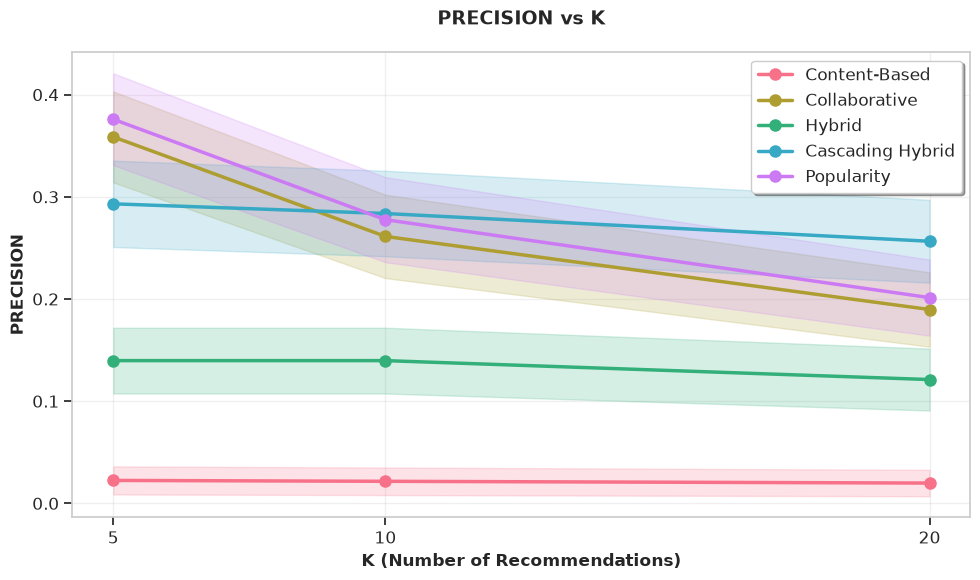

In [12]:
fig = visualizer.plot_metric_trend('precision', figsize=(10, 6))
plt.show()

### 5.2 Recall@K Trend

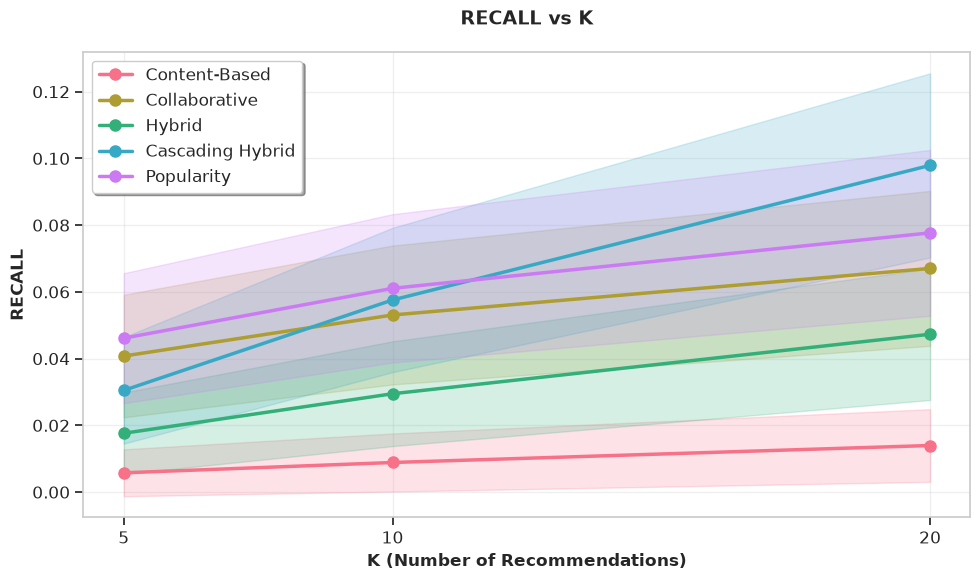

In [13]:
fig = visualizer.plot_metric_trend('recall', figsize=(10, 6))
plt.show()

### 5.3 NDCG@K Trend

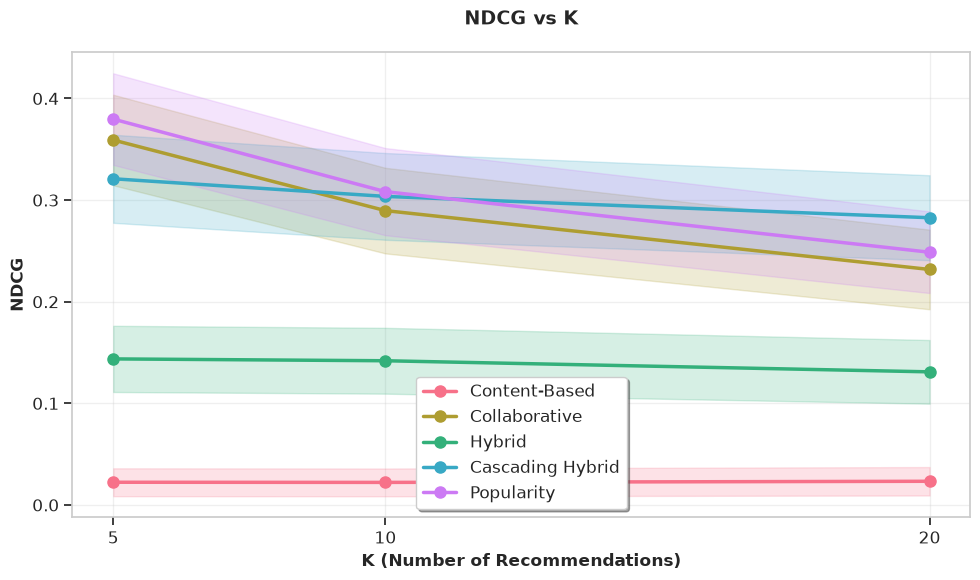

In [14]:
fig = visualizer.plot_metric_trend('ndcg', figsize=(10, 6))
plt.show()

### 5.4 Model Comparison at K=10

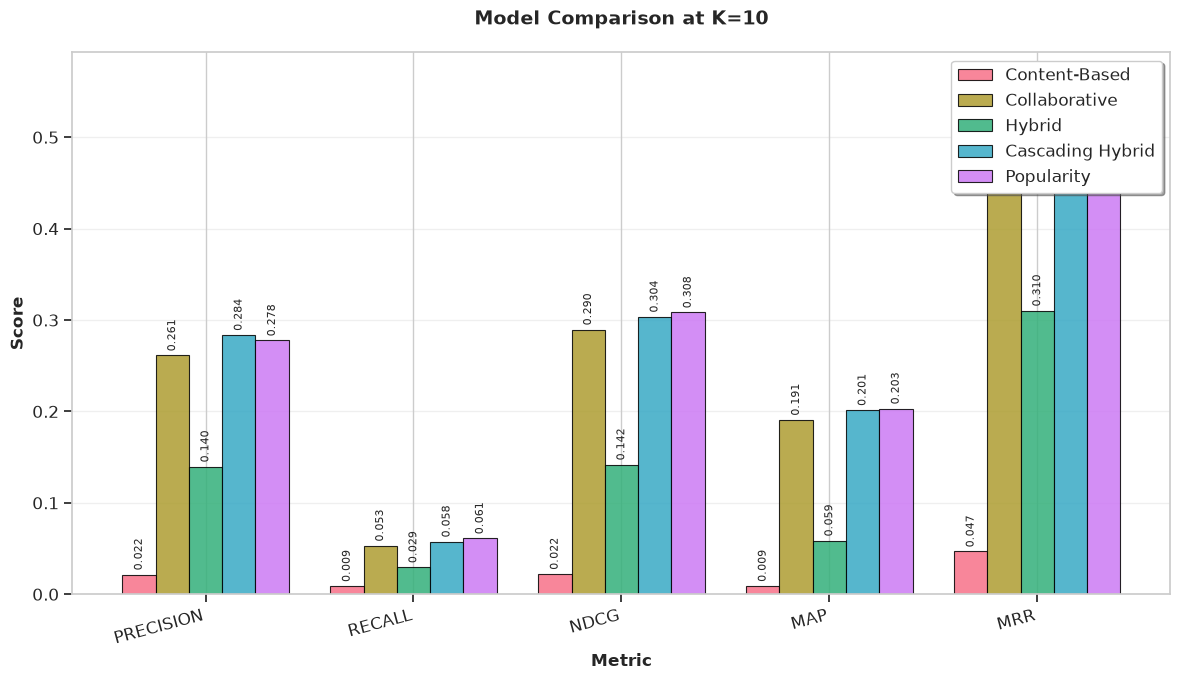

In [15]:
fig = visualizer.plot_model_comparison(k=10, figsize=(12, 7))
plt.show()

### 5.5 Performance Heatmap at K=10

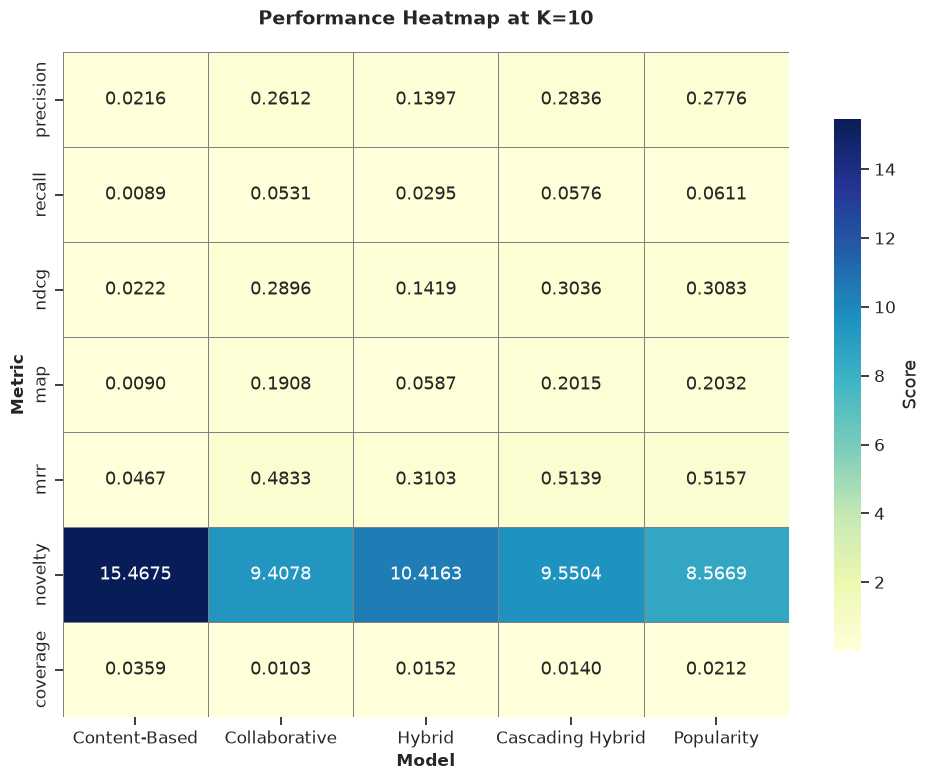

In [16]:
fig = visualizer.plot_all_metrics_heatmap(k=10, figsize=(10, 8))
plt.show()

### 5.6 Coverage vs Novelty Trade-off

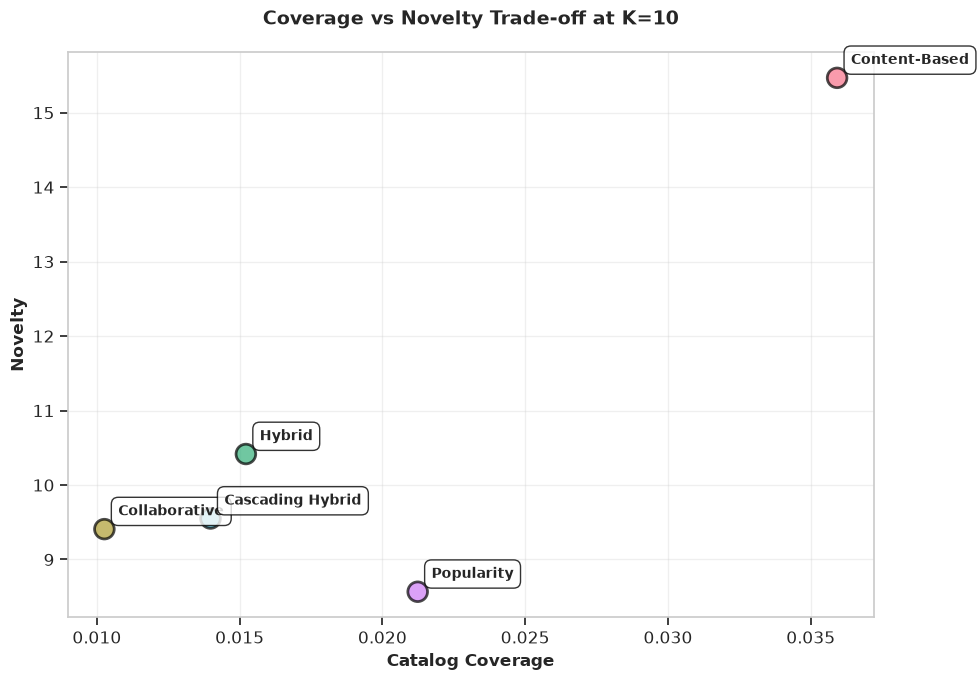

In [17]:
fig = visualizer.plot_coverage_novelty_tradeoff(k=10, figsize=(10, 7))
plt.show()

### 5.7 Radar Chart Comparison

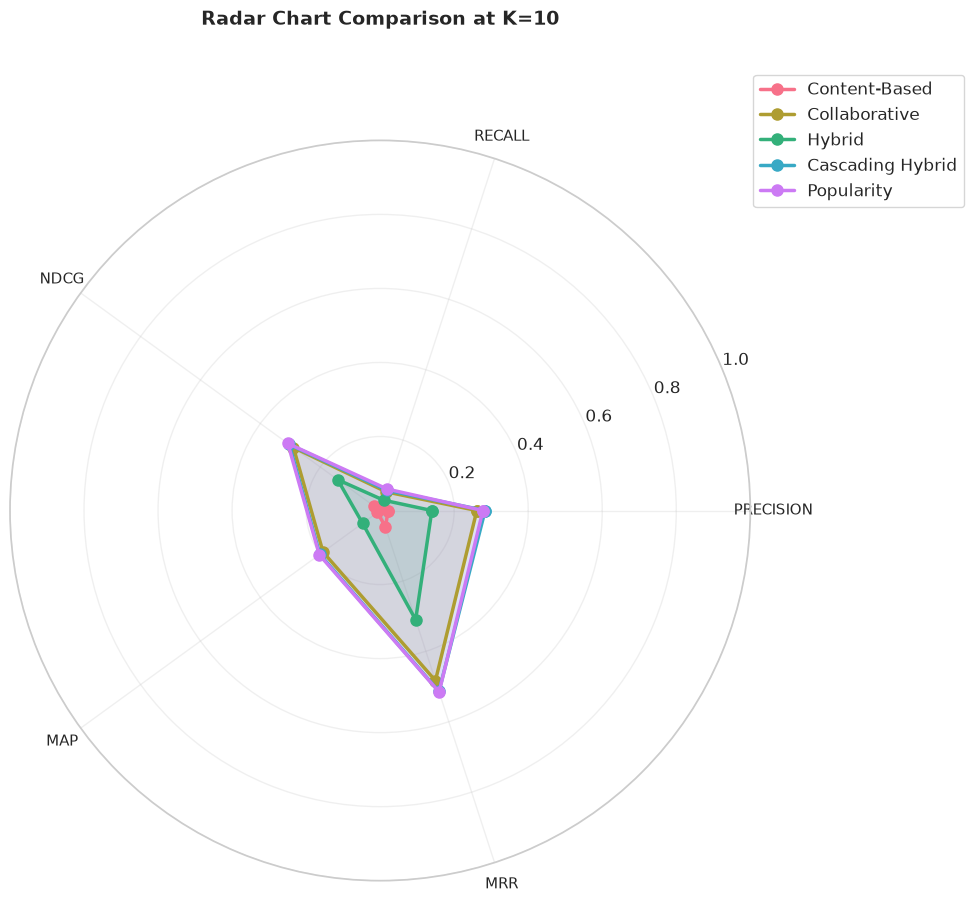

In [18]:
fig = visualizer.plot_radar_chart(k=10, figsize=(10, 10))
plt.show()

## 6. Save All Plots

In [19]:
visualizer.save_all_plots(output_dir="evaluation_plots")
print("All plots saved to evaluation_plots/")

INFO:src.evaluation.visualisation:All plots saved to evaluation_plots/


All plots saved to evaluation_plots/


## 7. Summary Statistics

In [20]:
print("=" * 80)
print("EVALUATION SUMMARY (K=10)")
print("=" * 80)

k10_results = results_df[results_df['k'] == 10]

for model in k10_results['model'].unique():
    model_data = k10_results[k10_results['model'] == model].iloc[0]
    print(f"\n{model.upper()}:")
    print(f"  Precision@10: {model_data['precision']:.4f}")
    print(f"  Recall@10:    {model_data['recall']:.4f}")
    print(f"  NDCG@10:      {model_data['ndcg']:.4f}")
    print(f"  MAP@10:       {model_data['map']:.4f}")
    print(f"  MRR:          {model_data['mrr']:.4f}")
    print(f"  Novelty:      {model_data['novelty']:.4f}")
    print(f"  Coverage:     {model_data['coverage']:.4f}")

print("\n" + "=" * 80)

EVALUATION SUMMARY (K=10)

CONTENT-BASED:
  Precision@10: 0.0216
  Recall@10:    0.0089
  NDCG@10:      0.0222
  MAP@10:       0.0090
  MRR:          0.0467
  Novelty:      15.4675
  Coverage:     0.0359

COLLABORATIVE:
  Precision@10: 0.2612
  Recall@10:    0.0531
  NDCG@10:      0.2896
  MAP@10:       0.1908
  MRR:          0.4833
  Novelty:      9.4078
  Coverage:     0.0103

HYBRID:
  Precision@10: 0.1397
  Recall@10:    0.0295
  NDCG@10:      0.1419
  MAP@10:       0.0587
  MRR:          0.3103
  Novelty:      10.4163
  Coverage:     0.0152

CASCADING HYBRID:
  Precision@10: 0.2836
  Recall@10:    0.0576
  NDCG@10:      0.3036
  MAP@10:       0.2015
  MRR:          0.5139
  Novelty:      9.5504
  Coverage:     0.0140

POPULARITY:
  Precision@10: 0.2776
  Recall@10:    0.0611
  NDCG@10:      0.3083
  MAP@10:       0.2032
  MRR:          0.5157
  Novelty:      8.5669
  Coverage:     0.0212

